# Import Packages

In [18]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Loading and exploring data

### Reading data with Pandas

In [103]:
df = pd.read_excel("houston_2017.xlsx")

### Explore data

In [106]:
df.head()

,Station,Name,Date,Month,DailyRain,AvgWind,TempMin,TempMax
0,USW00012960,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",2017-01-01,1,0.01,3.13,63,75
1,USW00012960,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",2017-01-02,1,1.29,6.26,52,74
2,USW00012960,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",2017-01-03,1,0.00,8.50,48,76
3,USW00012960,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",2017-01-04,1,0.00,7.83,42,53
4,USW00012960,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",2017-01-05,1,0.00,7.16,44,56


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Station    365 non-null    object        
 1   Name       365 non-null    object        
 2   Date       365 non-null    datetime64[ns]
 3   Month      365 non-null    int64         
 4   DailyRain  365 non-null    float64       
 5   AvgWind    365 non-null    float64       
 6   TempMin    365 non-null    int64         
 7   TempMax    365 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 22.9+ KB


### Convert from Fahrenheit to Celsius

### To optimize performance
I optimized performance by replacing Python loops with NumPy vectorized operations

#### Convert to NumPy arrays

In [247]:
temp_max_f = df['TempMax'].to_numpy()
temp_min_f = df['TempMin'].to_numpy()

In [249]:
# temp_max_c_loop = []
# for f_temp in df['TempMax']:
#    c_temp = (f_temp - 32) * 5/9
#    temp_max_c_loop.append(c_temp)

# temp_min_c_loop = []
# for f_temp in df['TempMin']:
#    c_temp = (f_temp - 32) * 5/9
#    temp_min_c_loop.append(c_temp)

#### To convert from Fahrenheit to Celsius i have to use this equation Celsius = (F - 32) × 5/9 °C

In [252]:
temp_max_c = (temp_max_f - 32) * 5/9
temp_min_c = (temp_min_f - 32) * 5/9

In [278]:
df['TempMax_C'] = temp_max_c
df['TempMin_C'] = temp_min_c

 ### Visualization using Matplotlib

 ####  Temperature Trends

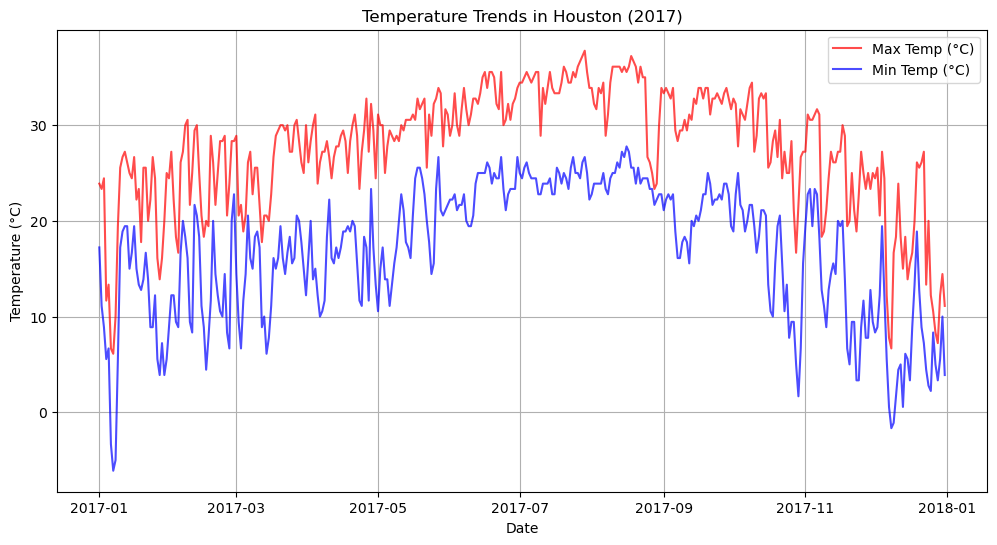

In [280]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['TempMax_C'], label='Max Temp (°C)', color='red', alpha=0.7)
plt.plot(df['Date'], df['TempMin_C'], label='Min Temp (°C)', color='blue', alpha=0.7)
plt.title('Temperature Trends in Houston (2017)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

### Top Windiest Days

In [187]:
top_windy_days = df.nlargest(3, 'AvgWind')[['Date', 'AvgWind']]

In [189]:
top_windy_days

,Date,AvgWind
239,2017-08-28,23.49
240,2017-08-29,21.70
118,2017-04-29,18.57


### Pearson Correlation: Relation between Rain and Wind

In [192]:
rain = df['DailyRain'].to_numpy()
wind = df['AvgWind'].to_numpy()

In [194]:
corr, p_val_corr = stats.pearsonr(rain, wind)

In [196]:
print(f"Pearson Correlation (Rain and Wind): {corr:.3f}")

Pearson Correlation (Rain and Wind): 0.222


The result was 0.22, which indicates a weak positive correlation

### Linear Regression

In [200]:
slope, intercept, r_value, p_value, std_err = stats.linregress(temp_min_c, temp_max_c)

#### Linear Regression R-squared

In [222]:
print(f"Linear Regression R-squared: {r_value**2:.3f}")

print(slope,std_err,r_value)


Linear Regression R-squared: 0.753
0.7830376616097682 0.023568908505324452 0.8674795502873919


### drawing the prediction line using the straight line equation

using equation : y^ = slope * x + intercept

In [207]:
regression_line = slope * df['TempMin_C'] + intercept

#### Show Linear Regression: Min vs Max Temp 

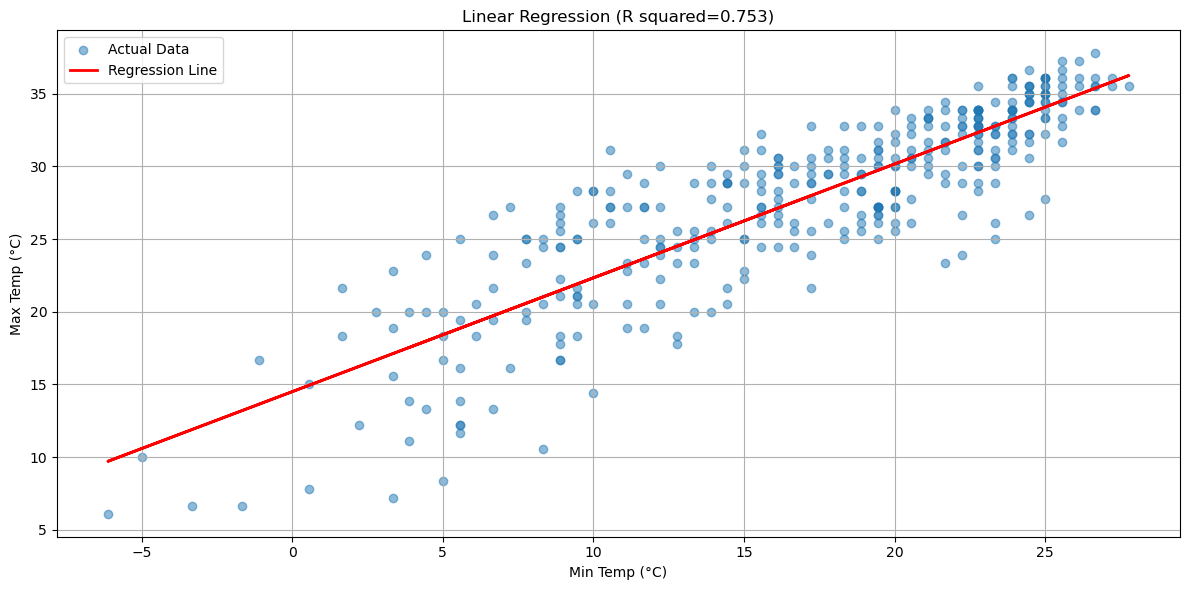

In [227]:
plt.figure(figsize=(12, 6))
plt.grid()
# plot the actual data points
plt.scatter(df['TempMin_C'], df['TempMax_C'], alpha=0.5, label='Actual Data')

plt.plot(df['TempMin_C'], regression_line, color='red', linewidth=2, label='Regression Line')
plt.title(f'Linear Regression (R squared={r_value**2:.3f})')
plt.xlabel('Min Temp (°C)')
plt.ylabel('Max Temp (°C)')
plt.legend()

plt.tight_layout()
plt.show()